# Parametric Curve Fitting

## Objective

The objective is to estimate the unknown parameters of a given
parametric curve from the provided `(x, y)` observations.

The unknown parameters are:

- `theta` — rotation angle
- `M` — exponential growth/decay parameter
- `X` — horizontal translation

The parameter constraints are:

- `6 < t < 60`
- `0 < theta < 50 degrees`
- `-0.05 < M < 0.05`
- `0 < X < 100`

The fitted parameters are obtained by minimizing the residual error
between the observed data and the parametric model.

Import the Libraries and Understand the data

Step 1:Understanding of the data



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.Load the dataset
df = pd.read_csv("xy_data.csv")

# 2.Basic information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# 3.First 5 rows
print("\nFirst 5 rows:")
print(df.head())

# 4.Missing values
print("\nMissing values:")
print(df.isnull().sum())

# 5.Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 6.Statistical summary
print("\nStatistical summary:")
print(df.describe())

# 7.Check whether x and y are sorted
print("\nIs x sorted increasingly?",
      df["x"].is_monotonic_increasing)

print("Is y sorted increasingly?",
      df["y"].is_monotonic_increasing)

Shape: (1500, 2)

Columns:
['x', 'y']

First 5 rows:
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Missing values:
x    0
y    0
dtype: int64

Duplicate rows: 0

Statistical summary:
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510

Is x sorted increasingly? False
Is y sorted increasingly? False


What i observed from dataset

Dataset:xy_data.csv

Number of observations:
    1500

Features:
    x, y

Missing values:
    None

Duplicate rows:
    None

x range:
    approximately 59.66 to 109.23

y range:
    approximately 46.03 to 69.69

Point ordering:
    x and y are not monotonically sorted

Important observation:
    The dataset does not provide t explicitly.

**Visualize and understand the curve**

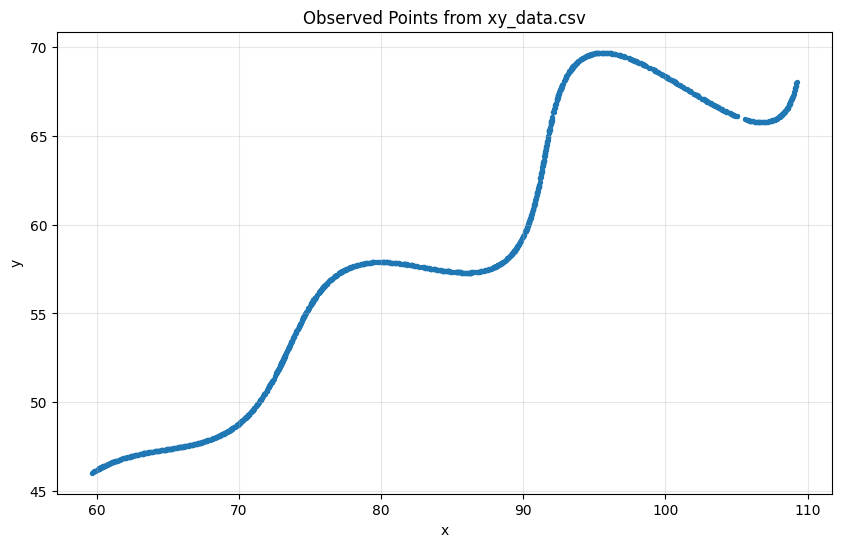

In [3]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["x"],
    df["y"],
    s=8
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Points from xy_data.csv")

plt.grid(True, alpha=0.3)
plt.show()

Why are we doing this?
This plot is actually a diagnostic.

If the CSV rows are ordered along the curve, this should look like a smooth curve.

If the rows are shuffled, it will look messy.

This helps us understand whether row order represents the parameter \(t\).

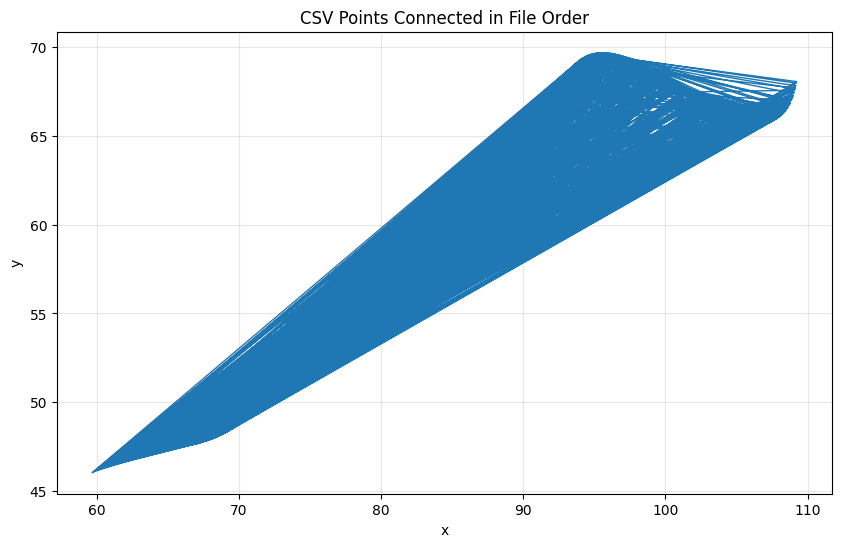

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x"],
    df["y"],
    linewidth=1
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("CSV Points Connected in File Order")

plt.grid(True, alpha=0.3)
plt.show()

**Understand the mathematical equation**

In [5]:

def parametric_curve(t, theta_deg, M, X):

    # Convert theta from degrees to radians
    theta = np.deg2rad(theta_deg)

    oscillation = np.exp(M * np.abs(t)) * np.sin(0.3 * t)

    # Parametric equations
    x = t * np.cos(theta) - oscillation * np.sin(theta) + X

    y = 42 + t * np.sin(theta) + oscillation * np.cos(theta)

    return x, y

Test the model with unknown valid parameters

In [6]:
t_test = np.linspace(6, 60, 1000)

x_test, y_test = parametric_curve(
    t_test,
    theta_deg=20,
    M=0.01,
    X=40
)

print("Number of generated points:", len(x_test))
print("First 5 x values:", x_test[:5])
print("First 5 y values:", y_test[:5])

Number of generated points: 1000
First 5 x values: [45.28448398 45.33647219 45.38855453 45.44073076 45.49300063]
First 5 y values: [45.02382599 45.03903305 45.05398148 45.06867193 45.08310514]


Plot the test curve

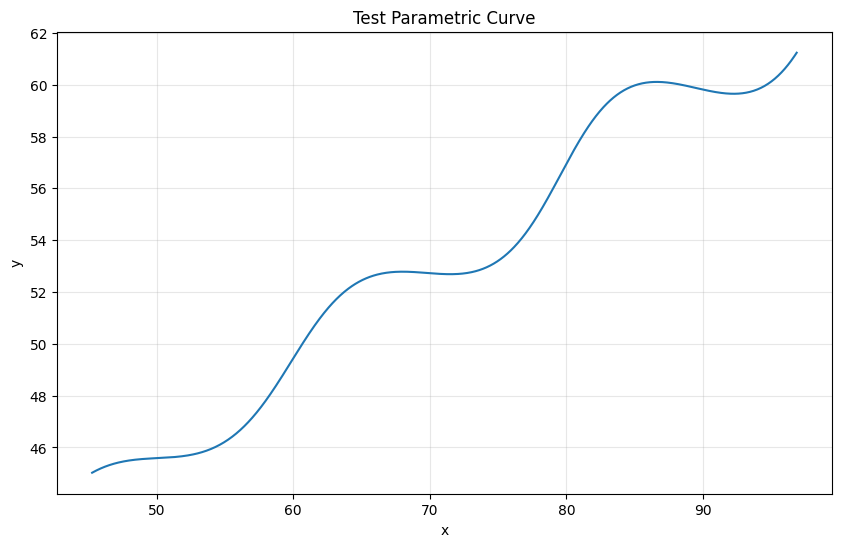

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(x_test, y_test)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Test Parametric Curve")

plt.grid(True, alpha=0.3)
plt.show()

Compare the mathematical curve with your actual data

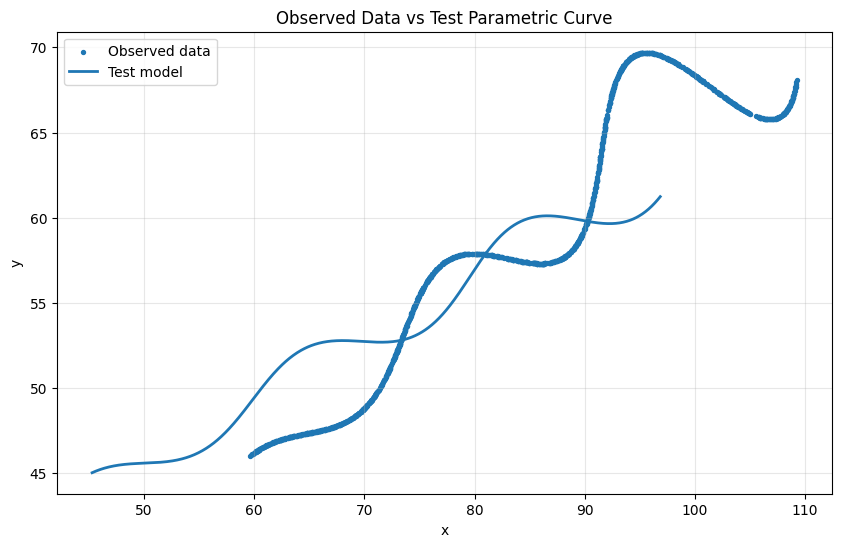

In [8]:
plt.figure(figsize=(10, 6))

# Actual data
plt.scatter(
    df["x"],
    df["y"],
    s=8,
    label="Observed data"
)

# Test mathematical curve
plt.plot(
    x_test,
    y_test,
    linewidth=2,
    label="Test model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Data vs Test Parametric Curve")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Why i get

Because i deliberately chose arbitrary parameters, the test curve should not necessarily match the data.

We're testing:

Can our Python function generate a valid curve from the mathematical equation?

We're not trying to fit the data yet.

**Understand the three parameters**

Before moving to optimization, we should understand what each parameter does.

Experiment A — Change X

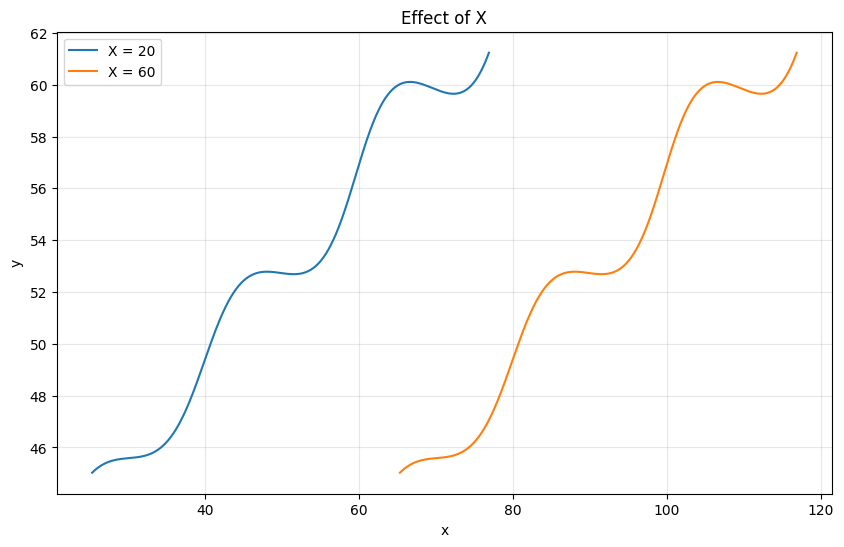

In [9]:
t_test = np.linspace(6, 60, 1000)

x1, y1 = parametric_curve(t_test, 20, 0.01, 20)
x2, y2 = parametric_curve(t_test, 20, 0.01, 60)

plt.figure(figsize=(10, 6))

plt.plot(x1, y1, label="X = 20")
plt.plot(x2, y2, label="X = 60")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of X")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

What should i observe?

Changing X should shift the curve horizontally.
Because:

 x(t)=...+X

while X does not appear in the y equation.

So:

X↑⇒curve shifts right

Experiment B — Change θ

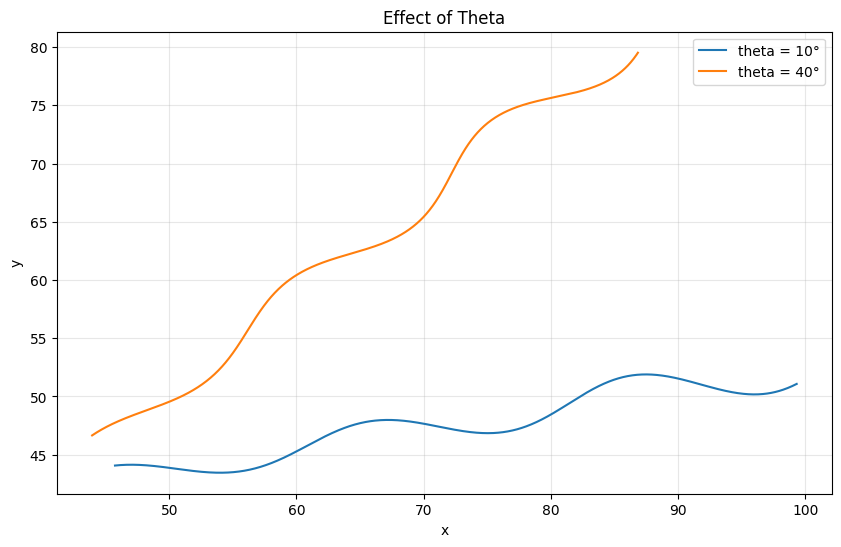

In [10]:
x1, y1 = parametric_curve(t_test, 10, 0.01, 40)
x2, y2 = parametric_curve(t_test, 40, 0.01, 40)

plt.figure(figsize=(10, 6))

plt.plot(x1, y1, label="theta = 10°")
plt.plot(x2, y2, label="theta = 40°")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of Theta")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

I tested:

$$ \theta=10^\circ $$

and

$$ \theta=40^\circ $$
What i observe

Changing \(\theta\) changes the orientation and vertical progression of the curve.

Why?

Because \(\theta\) appears in both equations:

$$ x(t)=t\cos\theta-\cdots\sin\theta+X $$

and

$$ y(t)=42+t\sin\theta+\cdots\cos\theta $$

So changing \(\theta\) affects both:

the x-direction component
the y-direction component

Experiment C — Change M

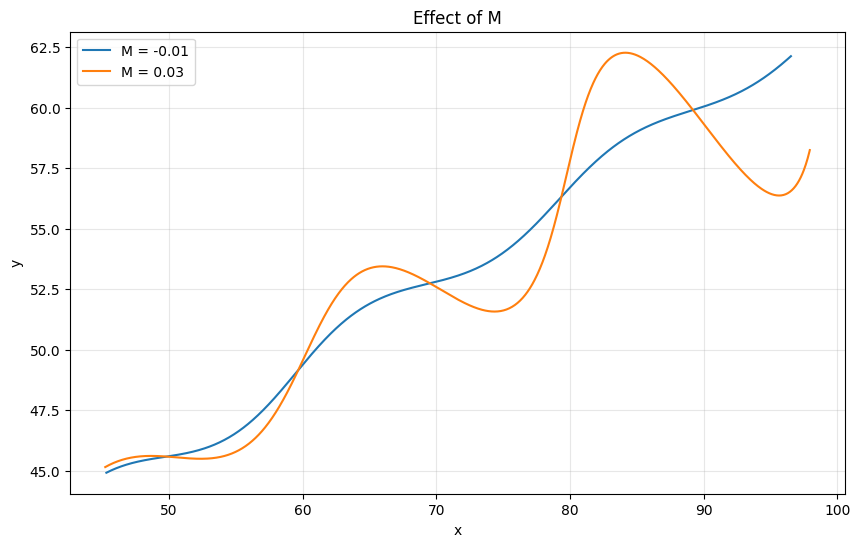

In [11]:
x1, y1 = parametric_curve(t_test, 20, -0.01, 40)
x2, y2 = parametric_curve(t_test, 20, 0.03, 40)

plt.figure(figsize=(10, 6))

plt.plot(x1, y1, label="M = -0.01")
plt.plot(x2, y2, label="M = 0.03")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of M")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

What i observe

The curves have similar overall movement, but their oscillations behave differently.

For:

M=-0.01

the oscillatory component becomes relatively smaller as \(t\) increases.

For:

 M=0.03

the oscillatory component becomes much stronger as \(t\) increases.

This comes from:

$$ e^{M|t|} $$

If \(M>0\):

$$ e^{M|t|} $$

increases with \(t\).

If \(M<0\):

$$ e^{M|t|} $$

decreases with \(t\).

##Recovering the Latent Parameter t

The given CSV file contains only x and y coordinates, while the
parametric model is defined using an additional parameter t.

To avoid treating every t value as an independent optimization
variable, we derive t from the observed coordinates using the
rotational structure of the parametric equations.

For a candidate theta and X:

t = (x - X) cos(theta) + (y - 42) sin(theta)

This allows the latent t corresponding to each observed point to
be calculated directly.

Implement the t calculation

Test with arbitrary parameters

In [12]:
def estimate_t(x, y, theta_deg, X):

    theta = np.deg2rad(theta_deg)

    t = (
        (x - X) * np.cos(theta)
        + (y - 42) * np.sin(theta)
    )

    return t

Check whether the estimated t values satisfy the constraint

In [13]:
theta_test = 20
X_test = 40

t_estimated = estimate_t(
    df["x"].values,
    df["y"].values,
    theta_test,
    X_test
)

print("First 10 estimated t values:")
print(t_estimated[:10])

print("\nMinimum estimated t:", t_estimated.min())
print("Maximum estimated t:", t_estimated.max())

First 10 estimated t values:
[50.84629764 36.45973034 20.50946599 44.96908109 66.19644025 29.70909508
 40.86159505 55.39644495 71.76659235 39.29764699]

Minimum estimated t: 19.850855657914618
Maximum estimated t: 73.96890978837631


In [14]:
valid_mask = (
    (t_estimated > 6) &
    (t_estimated < 60)
)

print("Total points:", len(t_estimated))
print("Points satisfying 6 < t < 60:", valid_mask.sum())
print("Points outside the valid range:", (~valid_mask).sum())

Total points: 1500
Points satisfying 6 < t < 60: 1145
Points outside the valid range: 355


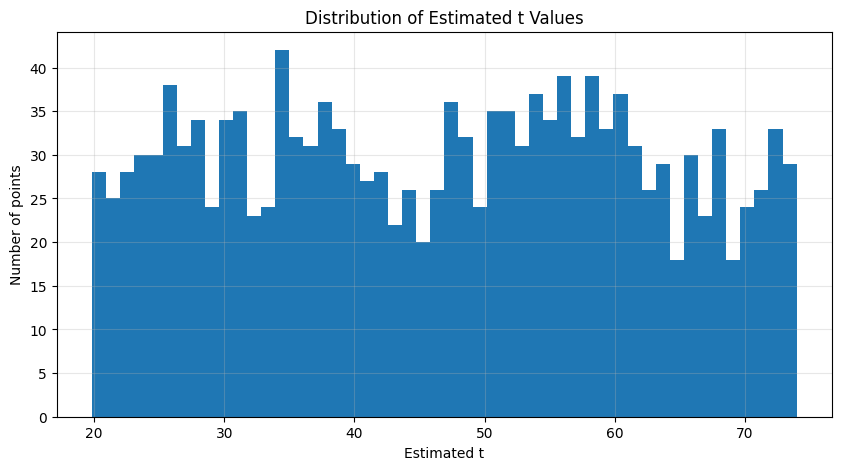

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(t_estimated, bins=50)

plt.xlabel("Estimated t")
plt.ylabel("Number of points")
plt.title("Distribution of Estimated t Values")

plt.grid(True, alpha=0.3)
plt.show()

**Calculate the observed oscillation**

In [16]:
def calculate_components(x, y, theta_deg, M, X):


    theta = np.deg2rad(theta_deg)

    # Recover t from the observed point
    t = (
        (x - X) * np.cos(theta)
        + (y - 42) * np.sin(theta)
    )

    # Observed perpendicular component
    A_observed = (
        -(x - X) * np.sin(theta)
        + (y - 42) * np.cos(theta)
    )

    # Model-predicted oscillatory component
    A_model = (
        np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
    )

    return t, A_observed, A_model

Again, use arbitrary values

In [17]:
theta_test = 20
M_test = 0.01
X_test = 40

t_test, A_observed, A_model = calculate_components(
    df["x"].values,
    df["y"].values,
    theta_test,
    M_test,
    X_test
)

print("First 10 t values:")
print(t_test[:10])

print("\nFirst 10 observed A values:")
print(A_observed[:10])

print("\nFirst 10 model A values:")
print(A_model[:10])

First 10 t values:
[50.84629764 36.45973034 20.50946599 44.96908109 66.19644025 29.70909508
 40.86159505 55.39644495 71.76659235 39.29764699]

First 10 observed A values:
[-1.70915464 -0.06723709 -2.87667311  0.35887846  3.41475919 -3.99601197
  1.71688526  2.21843815 -0.67210297  1.52277257]

First 10 model A values:
[ 0.72932535 -1.43754144 -0.1595648   1.2514894   1.64102194  0.65946217
 -0.45601036 -1.37488104  0.91208518 -1.03874328]


Calculate the residual

In [18]:
residuals = A_observed - A_model

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-2.43847999  1.37030435 -2.71710832 -0.89261094  1.77373725 -4.65547414
  2.17289561  3.5933192  -1.58418815  2.56151584]


Calculate an mean absolute error

In [19]:
mae = np.mean(np.abs(residuals))

print("Mean Absolute Error:", mae)

Mean Absolute Error: 3.1811591231434235


Compare two arbitrary parameter sets

In [20]:
def calculate_mae(theta_deg, M, X):

    t, A_observed, A_model = calculate_components(
        df["x"].values,
        df["y"].values,
        theta_deg,
        M,
        X
    )

    residuals = A_observed - A_model

    return np.mean(np.abs(residuals))

In [21]:
error_1 = calculate_mae(20, 0.01, 40)
error_2 = calculate_mae(35, -0.02, 70)

print("Error for parameter set 1:", error_1)
print("Error for parameter set 2:", error_2)

Error for parameter set 1: 3.1811591231434235
Error for parameter set 2: 5.7840712268591865


The first parameter set gives a smaller error:
$$ 3.181 < 5.784 $$

Therefore:
Parameter set 1 currently fits the observed data better than parameter set 2 according to our diagnostic objective.

In [22]:
from scipy.optimize import least_squares

Create the residual function

**Start to Optimize the equation**

Create the residual function

In [23]:
def residual_function(params, x, y):
    theta_deg, M, X = params

    theta = np.deg2rad(theta_deg)


    # Recover latent t
    t = (
        (x - X) * np.cos(theta)
        + (y - 42) * np.sin(theta)
    )


    # Observed perpendicular component
    A_observed = (
        -(x - X) * np.sin(theta)
        + (y - 42) * np.cos(theta)
    )

    # Model prediction
    A_model = (
        np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
    )



    residuals = A_observed - A_model

    return residuals

Define the bounds

In [24]:
lower_bounds = [
    0.000001,   # theta > 0
    -0.049999,  # M > -0.05
    0.000001    # X > 0
]

upper_bounds = [
    49.999999,  # theta < 50
    0.049999,   # M < 0.05
    99.999999   # X < 100
]

above I'm using values just inside the boundaries because the assignment specifies strict inequalities:
$$0<θ<50$$

Choose an initial guess

In [25]:
initial_guess = [
    20.0,    # theta
    0.01,    # M
    40.0     # X
]

Run the optimizer

In [26]:
result = least_squares(
    residual_function,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    args=(df["x"].values, df["y"].values),
    verbose=1
)

`gtol` termination condition is satisfied.
Function evaluations 11, initial cost 1.1461e+04, final cost 9.1150e-09, first-order optimality 9.71e-11.


Display what the optimizer found

In [27]:
print("Optimization successful:", result.success)
print("Optimizer message:", result.message)

print("\nEstimated parameters:")
print("Theta:", result.x[0], "degrees")
print("M:", result.x[1])
print("X:", result.x[2])

print("\nFinal cost:", result.cost)

Optimization successful: True
Optimizer message: `gtol` termination condition is satisfied.

Estimated parameters:
Theta: 29.9999729321583 degrees
M: 0.029999996873059678
X: 54.99999821279947

Final cost: 9.114989680316757e-09


Check the residual after optimization

In [28]:
optimized_residuals = result.fun

print("Mean absolute residual:",
      np.mean(np.abs(optimized_residuals)))

print("Maximum absolute residual:",
      np.max(np.abs(optimized_residuals)))

print("Minimum residual:",
      optimized_residuals.min())

print("Maximum residual:",
      optimized_residuals.max())

Mean absolute residual: 2.5598054385554665e-06
Maximum absolute residual: 1.7615054843878042e-05
Minimum residual: -1.4854870455105473e-05
Maximum residual: 1.7615054843878042e-05


Check the inferred t values


In [29]:
theta_opt, M_opt, X_opt = result.x

t_opt = estimate_t(
    df["x"].values,
    df["y"].values,
    theta_opt,
    X_opt
)

print("Minimum t:", t_opt.min())
print("Maximum t:", t_opt.max())

valid_t = (t_opt > 6) & (t_opt < 60)

print("Valid t points:", valid_t.sum())
print("Invalid t points:", (~valid_t).sum())

Minimum t: 6.04940547271836
Maximum t: 59.99517070234954
Valid t points: 1500
Invalid t points: 0


## Generate the Fitted Parametric Curve

After estimating the unknown parameters, the next step is to
generate the parametric curve using the estimated values.

A dense, uniformly spaced set of t values is used over the valid
domain 6 < t < 60. The resulting x(t) and y(t) coordinates
represent the predicted curve.

The predicted curve is then compared visually and numerically
with the observed points from xy_data.csv.

Generate uniform t

In [30]:

n_curve_points = 5000

t_curve = np.linspace(
    6,
    60,
    n_curve_points
)

print("Number of curve points:", len(t_curve))
print("Minimum t:", t_curve.min())
print("Maximum t:", t_curve.max())

Number of curve points: 5000
Minimum t: 6.0
Maximum t: 60.0


Why 5,000?

Our original dataset has 1,500 points.

We're generating a denser curve so that the mathematical curve appears smooth and our validation isn't dependent on a sparse sampling.

Generate the predicted curve

In [31]:
x_pred, y_pred = parametric_curve(
    t_curve,
    theta_opt,
    M_opt,
    X_opt
)

print("Generated predicted curve.")
print("x range:", x_pred.min(), "to", x_pred.max())
print("y range:", y_pred.min(), "to", y_pred.max())

Generated predicted curve.
x range: 59.6131988943584 to 109.23313837421402
y range: 46.009703135629955 to 69.68560750015779


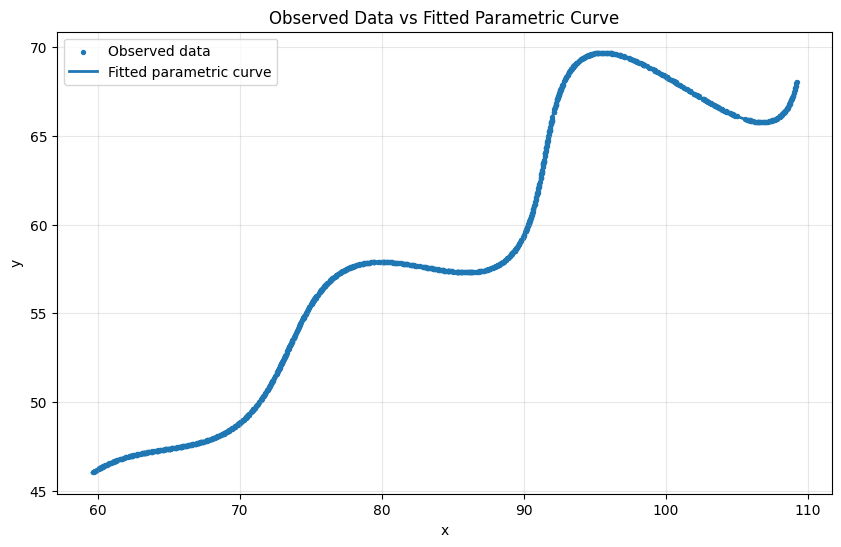

In [32]:
plt.figure(figsize=(10, 6))

# Observed data
plt.scatter(
    df["x"],
    df["y"],
    s=8,
    label="Observed data"
)

# Fitted mathematical curve
plt.plot(
    x_pred,
    y_pred,
    linewidth=2,
    label="Fitted parametric curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Data vs Fitted Parametric Curve")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

First compare the generated curve with the data geometrically

In [33]:
x_observed = df["x"].values
y_observed = df["y"].values

x_reconstructed, y_reconstructed = parametric_curve(
    t_opt,
    theta_opt,
    M_opt,
    X_opt
)

x_error = x_observed - x_reconstructed
y_error = y_observed - y_reconstructed

pointwise_l1 = np.abs(x_error) + np.abs(y_error)

print("Mean pointwise L1 distance:",
      np.mean(pointwise_l1))

print("Maximum pointwise L1 distance:",
      np.max(pointwise_l1))

print("Total pointwise L1 distance:",
      np.sum(pointwise_l1))

Mean pointwise L1 distance: 3.496758815430212e-06
Maximum pointwise L1 distance: 2.4062609355723907e-05
Total pointwise L1 distance: 0.005245138223145318


Why am i doing this?

For each observed point:

$$ (x_i,y_i) $$

we now have an estimated:

$$ t_i $$

Using that \(t_i\), we generate:

$$ (\hat{x_i},\hat{y_i}) $$

Then compare:

$$ |x_i-\hat{x_i}|+|y_i-\hat{y_i}| $$

This tells us:

How close is the actual point to the mathematical curve using the estimated parameters?

Sort the observed points by inferred t

In [34]:

sort_idx = np.argsort(t_opt)

t_sorted = t_opt[sort_idx]
x_sorted = x_observed[sort_idx]
y_sorted = y_observed[sort_idx]

print("First 10 sorted t values:")
print(t_sorted[:10])

print("\nLast 10 sorted t values:")
print(t_sorted[-10:])

print("\nIs t sorted?",
      np.all(np.diff(t_sorted) > 0))

First 10 sorted t values:
[6.04940547 6.13347596 6.20752329 6.25236869 6.25526918 6.2620161
 6.40553992 6.49781318 6.55286144 6.57620084]

Last 10 sorted t values:
[59.48273724 59.54137411 59.63101433 59.69371953 59.721304   59.72388467
 59.79935363 59.82597413 59.93133098 59.9951707 ]

Is t sorted? True


Check the spacing of the inferred t

In [35]:
t_gaps = np.diff(t_sorted)

print("Minimum t gap:", t_gaps.min())
print("Maximum t gap:", t_gaps.max())
print("Mean t gap:", t_gaps.mean())
print("Median t gap:", np.median(t_gaps))

Minimum t gap: 3.232050053725288e-05
Maximum t gap: 0.4001083405513839
Mean t gap: 0.0359878353766719
Median t gap: 0.025277242874970796


Create uniform t values

In [36]:
n_validation = 5000

t_uniform = np.linspace(
    t_sorted.min(),
    t_sorted.max(),
    n_validation
)

print("Validation t range:")
print(t_uniform.min(), "to", t_uniform.max())

print("Number of validation points:", len(t_uniform))

Validation t range:
6.04940547271836 to 59.99517070234954
Number of validation points: 5000


Interpolate the observed curve

In [37]:
x_expected = np.interp(
    t_uniform,
    t_sorted,
    x_sorted
)

y_expected = np.interp(
    t_uniform,
    t_sorted,
    y_sorted
)


Generate the predicted curve at exactly the same t

In [38]:
x_pred_uniform, y_pred_uniform = parametric_curve(
    t_uniform,
    theta_opt,
    M_opt,
    X_opt
)

In [39]:
l1_per_point = (
    np.abs(x_expected - x_pred_uniform)
    +
    np.abs(y_expected - y_pred_uniform)
)

mean_l1 = np.mean(l1_per_point)
total_l1 = np.sum(l1_per_point)
max_l1 = np.max(l1_per_point)


print("Mean L1 distance:", mean_l1)
print("Total L1 distance:", total_l1)
print("Maximum point L1 distance:", max_l1)

Mean L1 distance: 0.00017143881942233605
Total L1 distance: 0.8571940971116803
Maximum point L1 distance: 0.00907832130855013


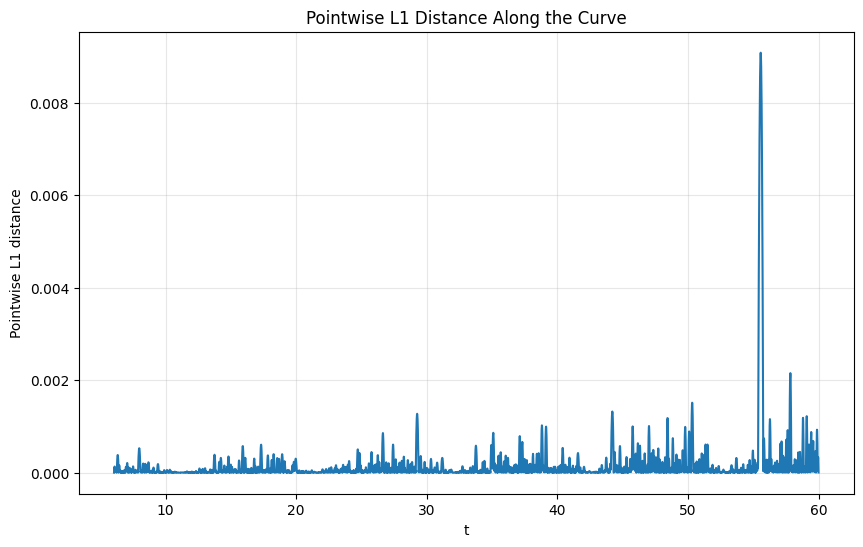

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    t_uniform,
    l1_per_point
)

plt.xlabel("t")
plt.ylabel("Pointwise L1 distance")
plt.title("Pointwise L1 Distance Along the Curve")

plt.grid(True, alpha=0.3)
plt.show()

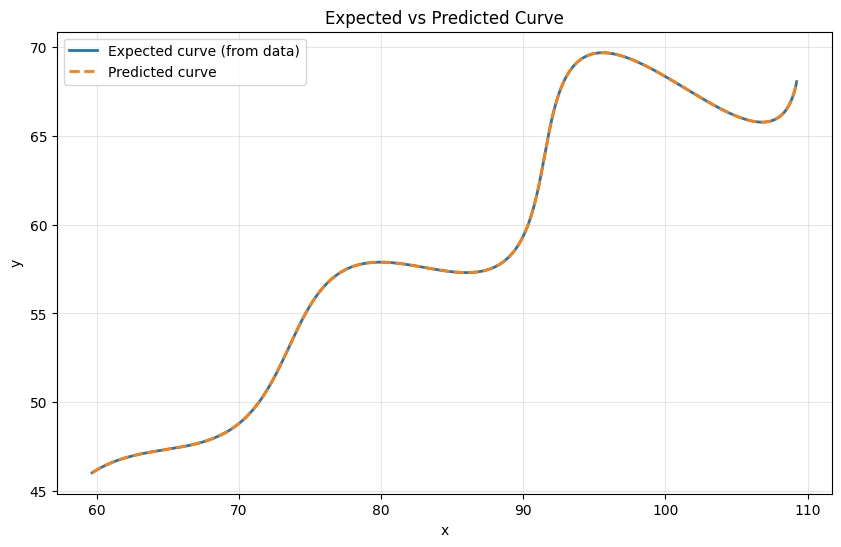

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_expected,
    y_expected,
    linewidth=2,
    label="Expected curve (from data)"
)

plt.plot(
    x_pred_uniform,
    y_pred_uniform,
    linestyle="--",
    linewidth=2,
    label="Predicted curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Expected vs Predicted Curve")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
print("theta =", theta_opt)
print("M =", M_opt)
print("X =", X_opt)
print("theta_rad =", theta_rad)

theta = 29.9999729321583
M = 0.029999996873059678
X = 54.99999821279947
theta_rad = 0.5235983031753398


In [44]:
theta_rad = np.deg2rad(theta_opt)

print("theta in degrees:", theta_opt)
print("theta in radians:", theta_rad)
print("M:", M_opt)
print("X:", X_opt)

theta in degrees: 29.9999729321583
theta in radians: 0.5235983031753398
M: 0.029999996873059678
X: 54.99999821279947


In [46]:

x = df["x"].values
y = df["y"].values

# FINAL VALIDATION
theta_final = result.x[0]
M_final = result.x[1]
X_final = result.x[2]

print("FINAL PARAMETERS")
print("----------------")
print(f"Theta = {theta_final:.6f} degrees")
print(f"M     = {M_final:.8f}")
print(f"X     = {X_final:.6f}")



print("\nPARAMETER BOUND CHECK")
print("---------------------")

print(f"Theta valid (0 < theta < 50): {0 < theta_final < 50}")
print(f"M valid (-0.05 < M < 0.05):   {-0.05 < M_final < 0.05}")
print(f"X valid (0 < X < 100):        {0 < X_final < 100}")


# 3. Calculate inferred t values
theta_rad = np.deg2rad(theta_final)

t_final = (
    (x - X_final) * np.cos(theta_rad)
    + (y - 42) * np.sin(theta_rad)
)

print("\nT RANGE CHECK")
print("-------------")
print(f"Minimum t = {t_final.min():.6f}")
print(f"Maximum t = {t_final.max():.6f}")

t_valid = np.all((t_final > 6) & (t_final < 60))

print(f"All t values satisfy 6 < t < 60: {t_valid}")


# 4. Calculate reconstruction error
A_observed = (
    -(x - X_final) * np.sin(theta_rad)
    + (y - 42) * np.cos(theta_rad)
)

A_model = (
    np.exp(M_final * np.abs(t_final))
    * np.sin(0.3 * t_final)
)

residuals = A_observed - A_model

mean_l1 = np.mean(np.abs(residuals))
max_l1 = np.max(np.abs(residuals))

print("\nRECONSTRUCTION ERROR")
print("--------------------")
print(f"Mean L1 error = {mean_l1:.10f}")
print(f"Max L1 error  = {max_l1:.10f}")


FINAL PARAMETERS
----------------
Theta = 29.999973 degrees
M     = 0.03000000
X     = 54.999998

PARAMETER BOUND CHECK
---------------------
Theta valid (0 < theta < 50): True
M valid (-0.05 < M < 0.05):   True
X valid (0 < X < 100):        True

T RANGE CHECK
-------------
Minimum t = 6.049405
Maximum t = 59.995171
All t values satisfy 6 < t < 60: True

RECONSTRUCTION ERROR
--------------------
Mean L1 error = 0.0000025598
Max L1 error  = 0.0000176151


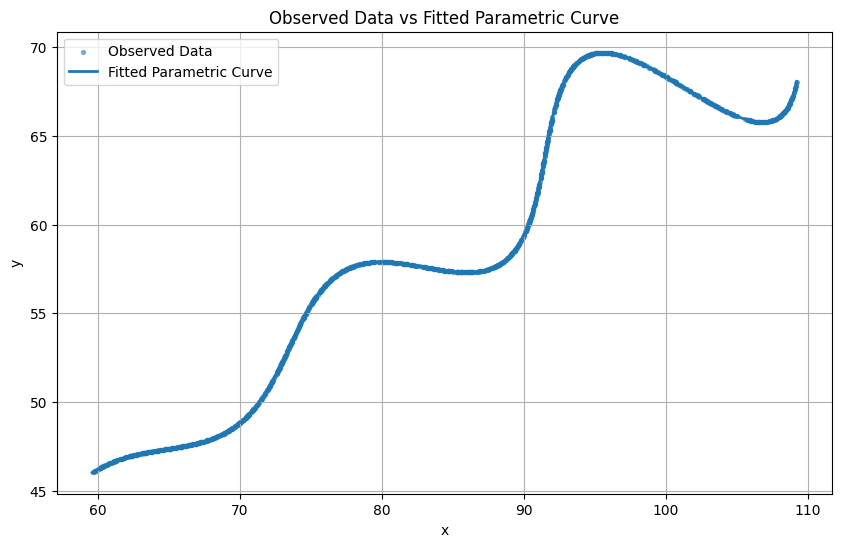

In [47]:
# FINAL FITTED CURVE

t_plot = np.linspace(6, 60, 5000)

x_plot, y_plot = parametric_curve(
    t_plot,
    theta_final,
    M_final,
    X_final
)

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    s=8,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_plot,
    y_plot,
    linewidth=2,
    label="Fitted Parametric Curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Data vs Fitted Parametric Curve")
plt.legend()
plt.grid(True)
plt.show()

Final parameter reporting

In [48]:
# FINAL PARAMETER REPORT

print("=" * 50)
print("FINAL PARAMETER ESTIMATION")
print("=" * 50)

print(f"Theta (degrees) : {theta_final:.6f}")
print(f"Theta (radians) : {theta_rad:.10f}")
print(f"M               : {M_final:.8f}")
print(f"X               : {X_final:.6f}")

print("\nParameter bounds:")
print("6 < t < 60")
print("0 < theta < 50 degrees")
print("-0.05 < M < 0.05")
print("0 < X < 100")

print("\nValidation:")
print(f"t minimum       : {t_final.min():.6f}")
print(f"t maximum       : {t_final.max():.6f}")
print(f"Mean L1 error   : {mean_l1:.10f}")
print(f"Max L1 error    : {max_l1:.10f}")

print("\nDesmos:")
print("https://www.desmos.com/calculator/hlieb10xmn")

FINAL PARAMETER ESTIMATION
Theta (degrees) : 29.999973
Theta (radians) : 0.5235983032
M               : 0.03000000
X               : 54.999998

Parameter bounds:
6 < t < 60
0 < theta < 50 degrees
-0.05 < M < 0.05
0 < X < 100

Validation:
t minimum       : 6.049405
t maximum       : 59.995171
Mean L1 error   : 0.0000025598
Max L1 error    : 0.0000176151

Desmos:
https://www.desmos.com/calculator/hlieb10xmn


## 9. Conclusion

The unknown parameters of the given parametric curve were estimated
using nonlinear least-squares optimization.

The resulting parameters are approximately:

$$
\theta \approx 30^\circ
$$

$$
M \approx 0.03
$$

$$
X \approx 55
$$

All parameter constraints are satisfied, and all 1500 observations
produce valid values of `t` within the specified range.

The fitted curve closely overlaps the observed data, with a very small
mean pointwise L1 reconstruction error.